<a href="https://colab.research.google.com/github/harmanbajwa2954/python_practice/blob/main/Wine_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering on Wine Dataset

---



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


## Importing Wine Dataset and Preprocessing

In [2]:
dataset = pd.read_csv("https://raw.githubusercontent.com/harmanbajwa2954/datasets/refs/heads/main/wine-clustering.csv")
df = pd.DataFrame(dataset)
df.head()


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
X = df.values
X

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [4]:
# Dataset overview
print("Shape of Dataset :", df.shape)
print("Dataset Information : ")
df.info()


Shape of Dataset : (178, 13)
Dataset Information : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [5]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

## Model Training

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42) # randomly assigning value of k=3
kmeans.fit(X_scaled)

centroids = kmeans.cluster_centers_
labels_kmeans = kmeans.labels_

In [8]:
#silhoute score
score_kmeans = silhouette_score(X_scaled, kmeans.labels_)
print("KMeans Silhouette Score:", round(score_kmeans, 3))

KMeans Silhouette Score: 0.184


### Applying Principal Component Analysis(PCA)

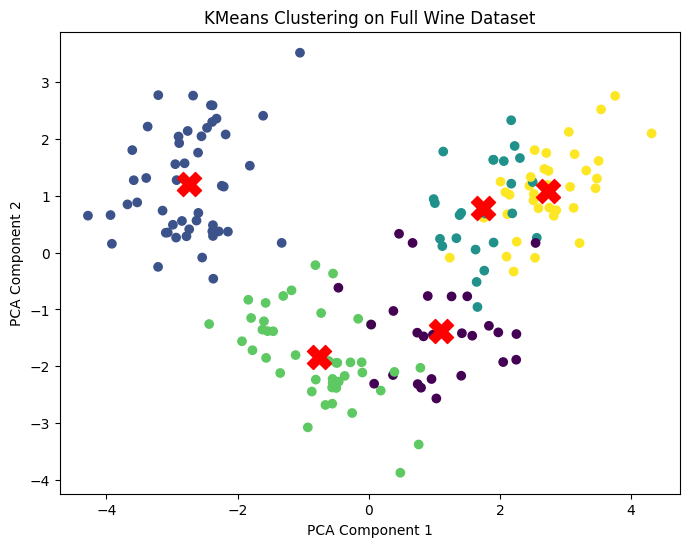

In [9]:
#PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', color='red', s=300)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clustering on Full Wine Dataset')
plt.show()

## Elbow Method

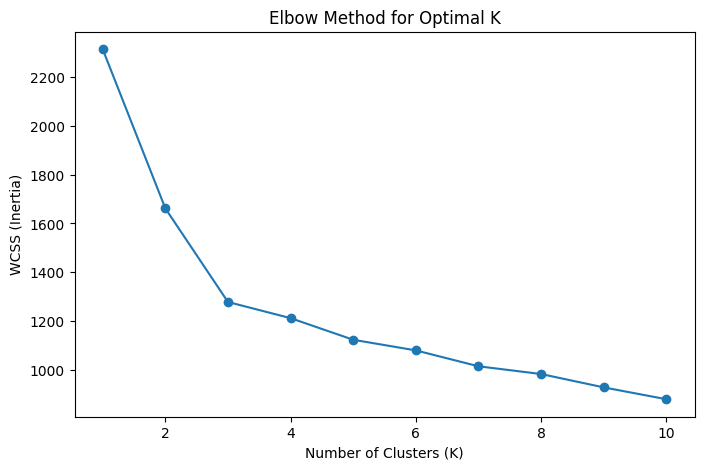

In [10]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.show()

K=2, Silhouette Score=0.259
K=3, Silhouette Score=0.285
K=4, Silhouette Score=0.260
K=5, Silhouette Score=0.202
K=6, Silhouette Score=0.237
K=7, Silhouette Score=0.204
K=8, Silhouette Score=0.157
K=9, Silhouette Score=0.150
K=10, Silhouette Score=0.144


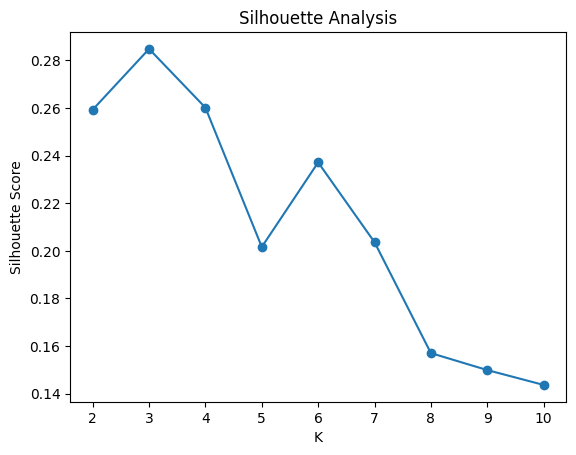

In [11]:
# Silhouette Score
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    temp_score = silhouette_score(X_scaled, labels)
    sil_scores.append(temp_score)
    print(f"K={k}, Silhouette Score={temp_score:.3f}")


plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

In [13]:
# linked
linked = linkage(X_scaled, 'ward')
linked


array([[  9.        ,  47.        ,   1.16411367,   2.        ],
       [131.        , 133.        ,   1.19160238,   2.        ],
       [ 11.        ,  12.        ,   1.20935571,   2.        ],
       [ 15.        ,  53.        ,   1.22551046,   2.        ],
       [ 92.        , 107.        ,   1.24538798,   2.        ],
       [ 34.        ,  37.        ,   1.26841838,   2.        ],
       [  0.        ,  20.        ,   1.28789316,   2.        ],
       [ 16.        ,  17.        ,   1.2917937 ,   2.        ],
       [164.        , 172.        ,   1.30048379,   2.        ],
       [ 22.        ,  29.        ,   1.33566687,   2.        ],
       [ 40.        ,  56.        ,   1.34447772,   2.        ],
       [104.        , 116.        ,   1.3521749 ,   2.        ],
       [ 23.        ,  24.        ,   1.36268788,   2.        ],
       [ 27.        ,  38.        ,   1.3653111 ,   2.        ],
       [140.        , 142.        ,   1.36740174,   2.        ],
       [ 63.        ,  98

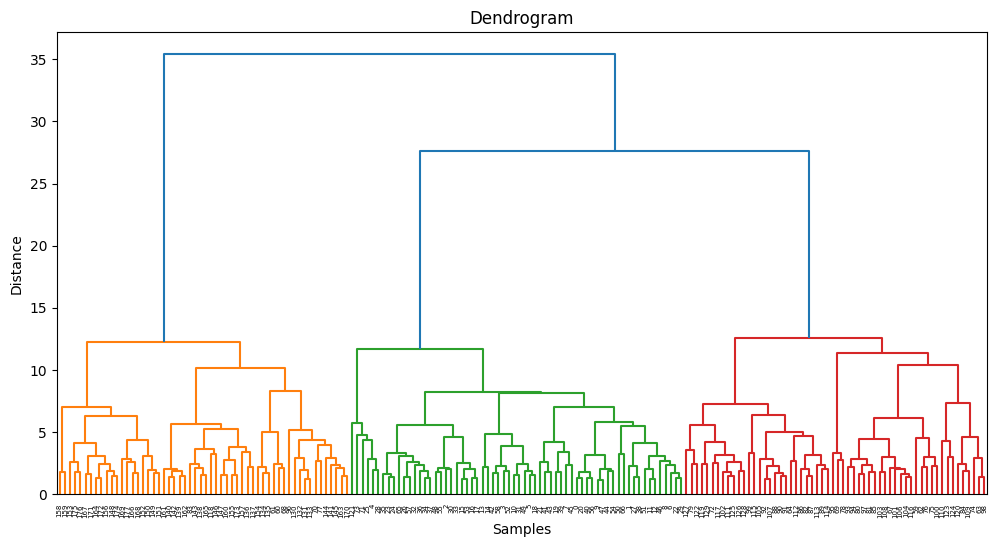

In [14]:
# Dendogram
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()